<a href="https://colab.research.google.com/github/gourim2523-arch/-case-study/blob/main/Case_Study_Supervised_Learning_17_06_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('/content/Training_data.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [4]:
data.shape

(5634, 21)

In [5]:
data.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


<Axes: xlabel='MonthlyCharges', ylabel='Count'>

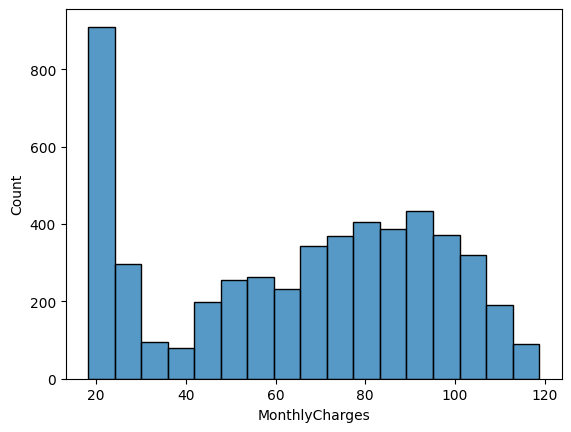

In [6]:
sns.histplot(data=data,x='MonthlyCharges')

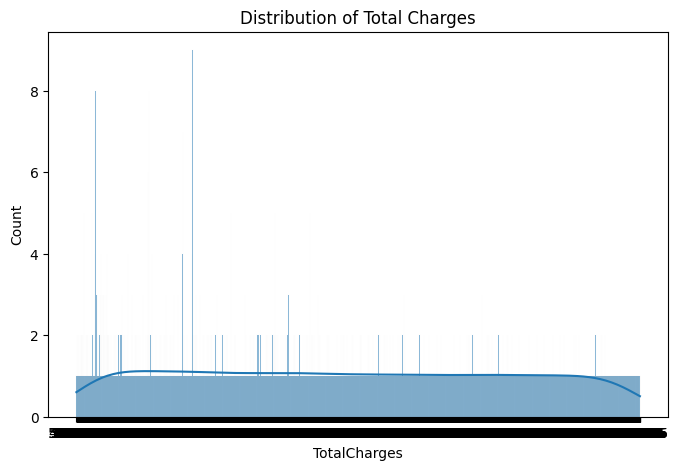

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(data['TotalCharges'],
             bins=30,kde=True)
plt.title('Distribution of Total Charges')
plt.show()



In [8]:
data['gender'] = data['gender'].fillna(data['gender'].mode()[0])
data['OnlineSecurity'] = data['OnlineSecurity'].fillna(data['OnlineSecurity'].mode()[0])
data['MonthlyCharges'] = data['MonthlyCharges'].fillna(data['MonthlyCharges'].median())
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

In [9]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5634 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


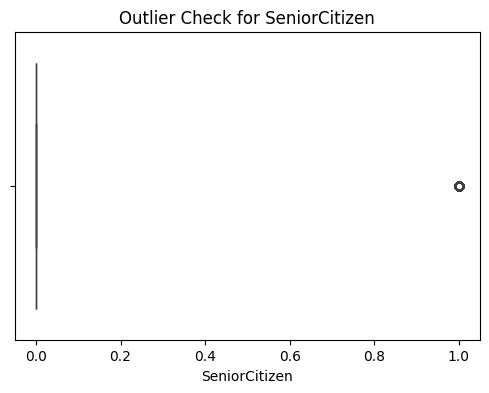

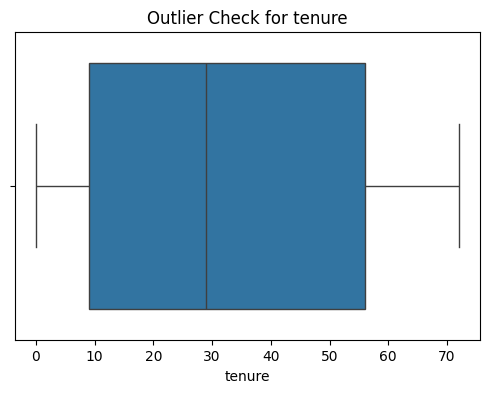

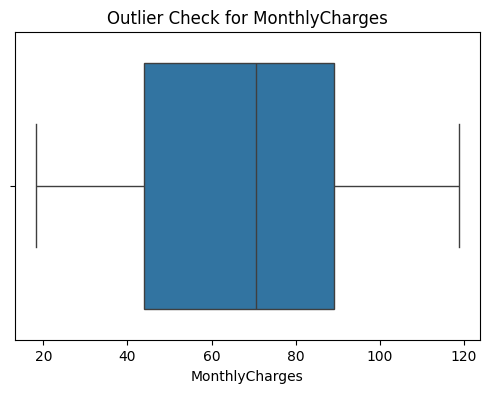

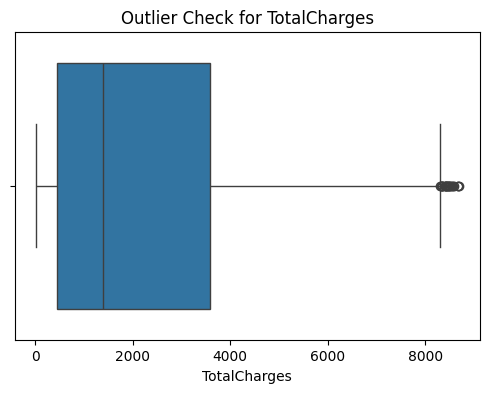

In [13]:

numeric_col = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(f'Outlier Check for {col}')
    plt.show()

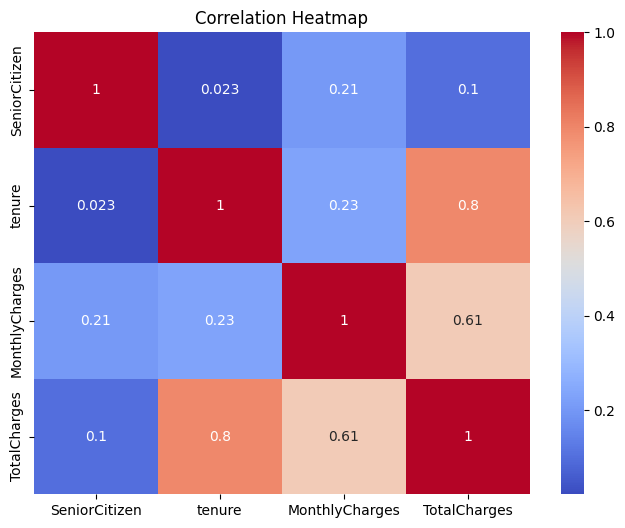

In [14]:
corr = data.corr(numeric_only = True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

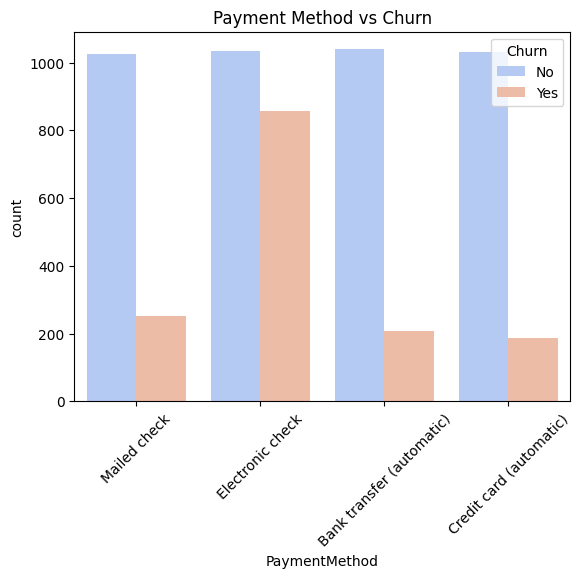

In [15]:
sns.countplot(x='PaymentMethod', hue='Churn', data=data, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Payment Method vs Churn')
plt.show()


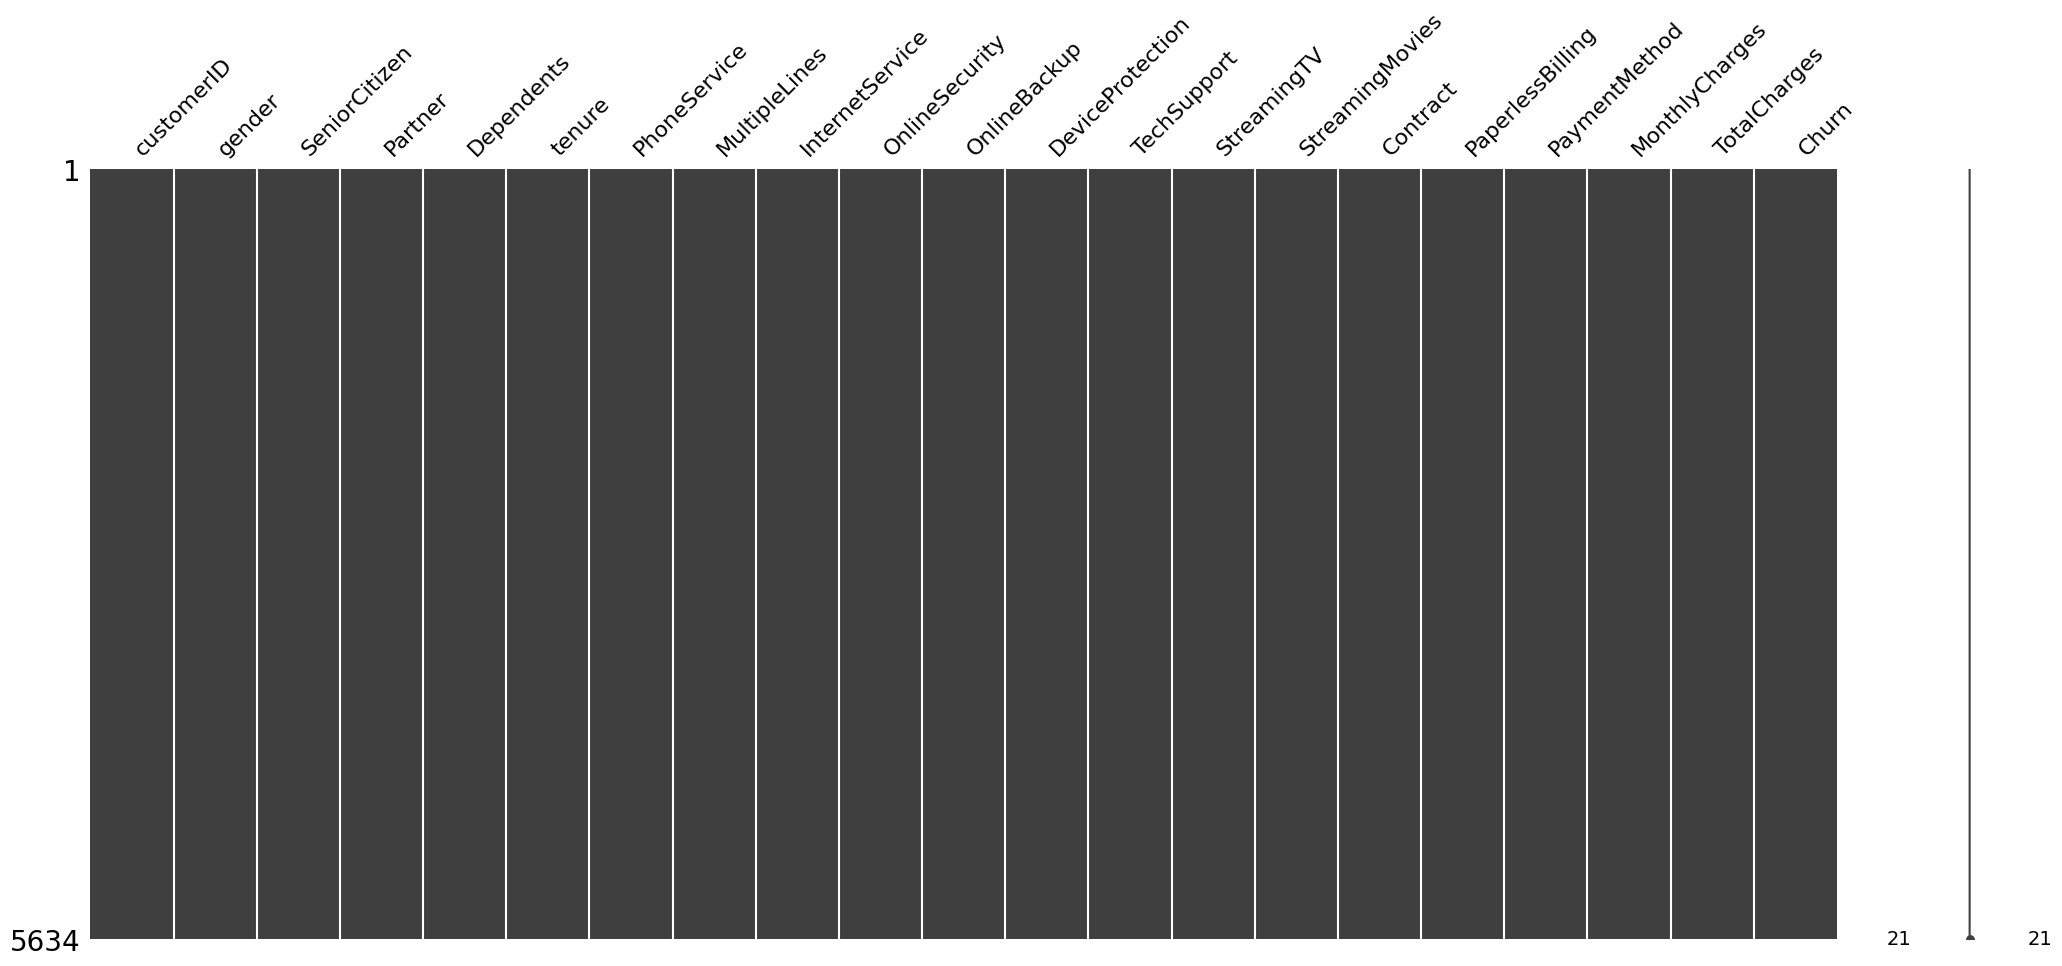

In [16]:
import missingno as msno
msno.matrix(data)
plt.show()

In [17]:
data['customerID'].unique()

array(['9509-MPYOD', '7746-AWNQW', '2208-UGTGR', ..., '4277-BWBML',
       '9110-HSGTV', '3402-XRIUO'], dtype=object)

In [18]:

data = data.drop('customerID', axis=1)


In [19]:
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()
data['gender'] = label_enc.fit_transform(data['gender'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,0,0,No,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,1,0,No,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,1,0,Yes,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,0,0,Yes,Yes,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [20]:
label_enc = LabelEncoder()
data['Partner'] = label_enc.fit_transform(data['Partner'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,0,0,0,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,1,0,0,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,1,0,1,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,0,0,1,Yes,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [21]:
label_enc = LabelEncoder()
data['Dependents'] = label_enc.fit_transform(data['Dependents'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,0,0,0,0,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,1,0,0,0,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,1,0,1,0,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,0,0,1,1,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [22]:
label_enc = LabelEncoder()
data['PhoneService'] = label_enc.fit_transform(data['PhoneService'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,0,0,0,0,28,0,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,1,0,0,0,56,1,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,1,0,1,0,39,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,0,0,1,1,43,0,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [23]:
label_enc = LabelEncoder()
data['MultipleLines'] = label_enc.fit_transform(data['MultipleLines'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,1,0,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,0,0,0,0,28,0,1,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,1,0,0,0,56,1,2,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,1,0,1,0,39,1,0,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,0,0,1,1,43,0,1,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [24]:
label_enc = LabelEncoder()
data['InternetService'] = label_enc.fit_transform(data['InternetService'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,1,0,2,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,0,0,0,0,28,0,1,0,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,1,0,0,0,56,1,2,1,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,1,0,1,0,39,1,0,2,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,0,0,1,1,43,0,1,0,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [25]:
data = pd.get_dummies(data,columns=['OnlineSecurity','OnlineBackup'],dtype = int)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,DeviceProtection,TechSupport,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes
0,0,0,0,0,35,1,0,2,No internet service,No internet service,...,Mailed check,20.75,700.45,No,0,1,0,0,1,0
1,0,0,0,0,28,0,1,0,Yes,Yes,...,Mailed check,35.75,961.40,No,1,0,0,1,0,0
2,1,0,0,0,56,1,2,1,No,No,...,Electronic check,98.60,5581.05,No,1,0,0,0,0,1
3,1,0,1,0,39,1,0,2,No internet service,No internet service,...,Bank transfer (automatic),20.45,790.00,No,0,1,0,0,1,0
4,0,0,1,1,43,0,1,0,No,Yes,...,Bank transfer (automatic),51.25,2151.60,No,1,0,0,0,0,1


In [26]:
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'OnlineSecurity_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes'],
      dtype='object')

In [27]:
data['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [28]:
data = pd.get_dummies(data,columns=['DeviceProtection','TechSupport','StreamingMovies','Contract'],dtype = int)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,StreamingTV,PaperlessBilling,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year
0,0,0,0,0,35,1,0,2,No internet service,No,...,0,0,1,0,0,1,0,0,1,0
1,0,0,0,0,28,0,1,0,No,Yes,...,1,0,0,1,1,0,0,1,0,0
2,1,0,0,0,56,1,2,1,Yes,No,...,0,1,0,0,0,0,1,1,0,0
3,1,0,1,0,39,1,0,2,No internet service,Yes,...,0,0,1,0,0,1,0,0,0,1
4,0,0,1,1,43,0,1,0,Yes,Yes,...,0,0,0,1,1,0,0,0,1,0


In [29]:
label_enc = LabelEncoder()
data['PaperlessBilling'] = label_enc.fit_transform(data['PaperlessBilling'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,StreamingTV,PaperlessBilling,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year
0,0,0,0,0,35,1,0,2,No internet service,0,...,0,0,1,0,0,1,0,0,1,0
1,0,0,0,0,28,0,1,0,No,1,...,1,0,0,1,1,0,0,1,0,0
2,1,0,0,0,56,1,2,1,Yes,0,...,0,1,0,0,0,0,1,1,0,0
3,1,0,1,0,39,1,0,2,No internet service,1,...,0,0,1,0,0,1,0,0,0,1
4,0,0,1,1,43,0,1,0,Yes,1,...,0,0,0,1,1,0,0,0,1,0


In [30]:
data = pd.get_dummies(data,columns=['StreamingTV','PaymentMethod',],dtype = int)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,PaperlessBilling,MonthlyCharges,...,Contract_Month-to-month,Contract_One year,Contract_Two year,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,35,1,0,2,0,20.75,...,0,1,0,0,1,0,0,0,0,1
1,0,0,0,0,28,0,1,0,1,35.75,...,1,0,0,1,0,0,0,0,0,1
2,1,0,0,0,56,1,2,1,0,98.60,...,1,0,0,0,0,1,0,0,1,0
3,1,0,1,0,39,1,0,2,1,20.45,...,0,0,1,0,1,0,1,0,0,0
4,0,0,1,1,43,0,1,0,1,51.25,...,0,1,0,0,0,1,1,0,0,0


In [31]:
label_enc = LabelEncoder()
data['Churn'] = label_enc.fit_transform(data['Churn'])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,PaperlessBilling,MonthlyCharges,...,Contract_Month-to-month,Contract_One year,Contract_Two year,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,35,1,0,2,0,20.75,...,0,1,0,0,1,0,0,0,0,1
1,0,0,0,0,28,0,1,0,1,35.75,...,1,0,0,1,0,0,0,0,0,1
2,1,0,0,0,56,1,2,1,0,98.60,...,1,0,0,0,0,1,0,0,1,0
3,1,0,1,0,39,1,0,2,1,20.45,...,0,0,1,0,1,0,1,0,0,0
4,0,0,1,1,43,0,1,0,1,51.25,...,0,1,0,0,0,1,1,0,0,0


3. Feature Engineering.

In [32]:
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'StreamingTV_No',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [33]:
data['CLV_Proxy'] = data['tenure'] * data['MonthlyCharges']
data['TenureMonthToMonth'] = data['tenure'] * data['Contract_Month-to-month']
data['TenureOneYear'] = data['tenure'] * data['Contract_One year']
data['TenureTwoYear'] = data['tenure'] * data['Contract_Two year']
data[['tenure', 'MonthlyCharges', 'CLV_Proxy', 'TenureMonthToMonth', 'TenureOneYear', 'TenureTwoYear']].head()

,tenure,MonthlyCharges,CLV_Proxy,TenureMonthToMonth,TenureOneYear,TenureTwoYear
0,35,20.75,726.25,0,35,0
1,28,35.75,1001.00,28,0,0
2,56,98.60,5521.60,56,0,0
3,39,20.45,797.55,0,0,39
4,43,51.25,2203.75,0,43,0


/tmp/ipykernel_1410/1390974183.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:top_n]], y=feature_names[indices[:top_n]], palette="viridis")


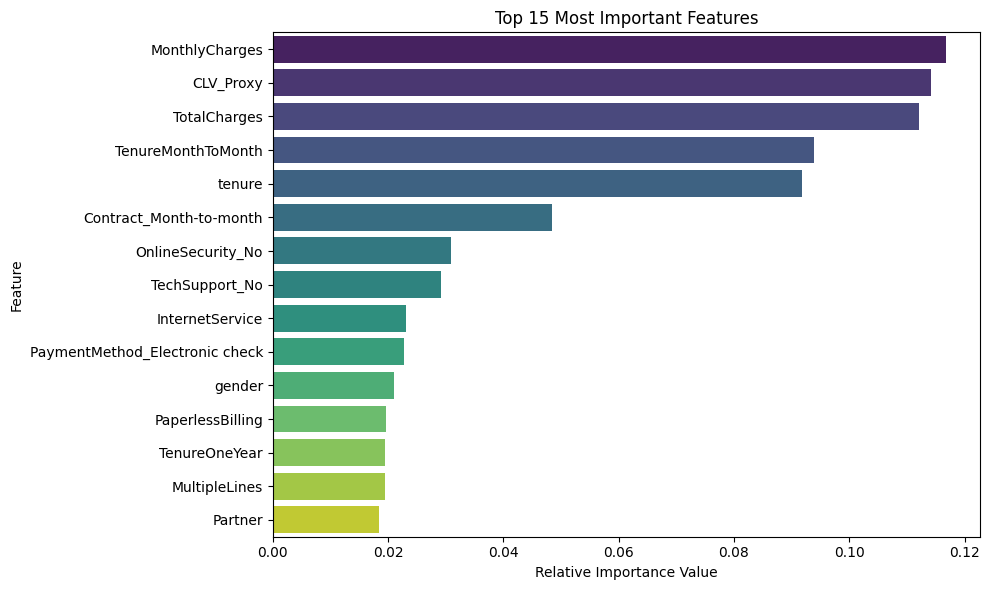

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np

if data['Churn'].dtype == 'object':
    data['Churn'] = data['Churn'].map({'No': 0, 'Yes': 1})

X = data.drop(columns=['Churn'])
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_names = X.columns


indices = np.argsort(importances)[::-1]
top_n = 15

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices[:top_n]], y=feature_names[indices[:top_n]], palette="viridis")
plt.title('Top 15 Most Important Features')
plt.xlabel('Relative Importance Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

if data['Churn'].dtype == 'object':
    data['Churn'] = data['Churn'].map({'No': 0, 'Yes': 1})

X = data.drop(columns=['Churn'])
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []

for name, model in models.items():
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

df_results = pd.DataFrame(results)
print(df_results)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.805679   0.654135  0.578073  0.613757  0.850844
1        Random Forest  0.795031   0.642276  0.524917  0.577697  0.839166
2              XGBoost  0.776398   0.593156  0.518272  0.553191  0.827245


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:23:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


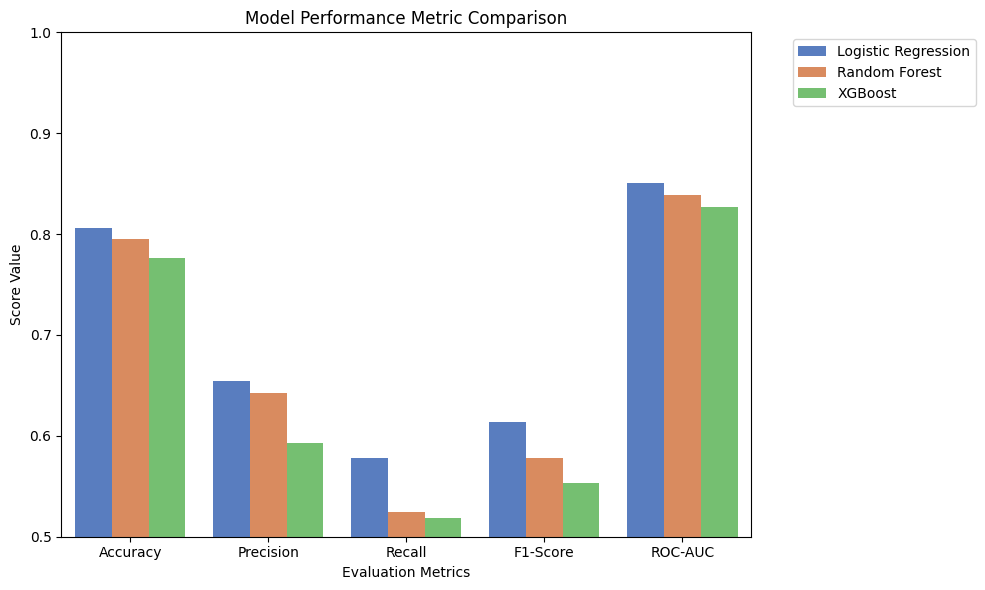

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

df_melted = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette="muted")
plt.ylim(0.5, 1.0)
plt.title("Model Performance Metric Comparison")
plt.ylabel("Score Value")
plt.xlabel("Evaluation Metrics")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]

}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("Tuning Random Forest...")
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print(f"Best RF Parameters: {rf_grid.best_params_}\n")

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=xgb_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("Tuning XGBoost...")
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
print(f"Best XGBoost Parameters: {xgb_grid.best_params_}\n")

Tuning Random Forest...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best RF Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Tuning XGBoost...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}



In [39]:
tuned_models = {
    'Tuned Random Forest': best_rf,
    'Tuned XGBoost': best_xgb
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tuned_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

df_tuned = pd.DataFrame(tuned_results)
print("Model Performance")
display(df_tuned)

Model Performance


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Random Forest,0.815439,0.678161,0.58804,0.629893,0.851480
1,Tuned XGBoost,0.811003,0.677419,0.55814,0.612022,0.851315
